# Marker Map

`HierarchyRun.marker_map` draws a **hierarchical marker map**: the cross-resolution
cluster tree on top, and beneath it a grid of each node's top-N marker genes.

- **rows** — per-node top-N markers, colored by the level they come from
  (`leiden_1.0` red / `leiden_2.0` green / `leiden_4.0` black).
- **columns** — every `icls` leaf (finest resolution), ordered by the hierarchy so
  the top tree is planar.
- **cell** — color = normalized mean expression (via the row's level colormap) and
  fraction of expressing cells (band height in `mode="band"`, dot area in `mode="dot"`).

It has two scopes, chosen by `icls`:

- `icls=None` (default) — the **full map** over every node.
- `icls="<id>"` — a **single path**: one lineage's per-level top-N markers.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import scanpy as sc
import sceleto as scl
import matplotlib.pyplot as plt
sc.settings.set_figure_params(facecolor="white", frameon=False)

## Data & hierarchy

Build a 3-resolution hierarchy exactly as in the [Markers tutorial](markers_tutorial.ipynb):
run `scl.markers.marker` at three Leiden resolutions and cross them with
`scl.markers.hierarchy`. `marker_map` reads everything it needs from the returned
`HierarchyRun` — no `adata` argument required.

In [2]:
adata = sc.read("/nfs3/SCMGL/smc03_sceleto/PANGEA_T&NK_v03_final.h5ad")

levels = ["leiden_1.0", "leiden_2.0", "leiden_4.0"]
marker_runs = {lv: scl.markers.marker(adata, lv) for lv in levels}
hr = scl.markers.hierarchy(adata, marker_runs.values())
print(hr.icls_path_df.shape[0], "icls leaves")

  Auto thres_fc: 2.85


  Auto thres_fc: 1.00


  Auto thres_fc: 2.49


43 icls leaves


## 1. The full map (default)

`hr.marker_map()` with no arguments draws the full map: every node's top-N markers
as bands (`mode="band"`, cell height = fraction of expressing cells), rows grouped
by lineage (`order="dfs"`). The block-diagonal structure shows each lineage lighting
up its own markers. `n_markers` sets how many top markers per node.

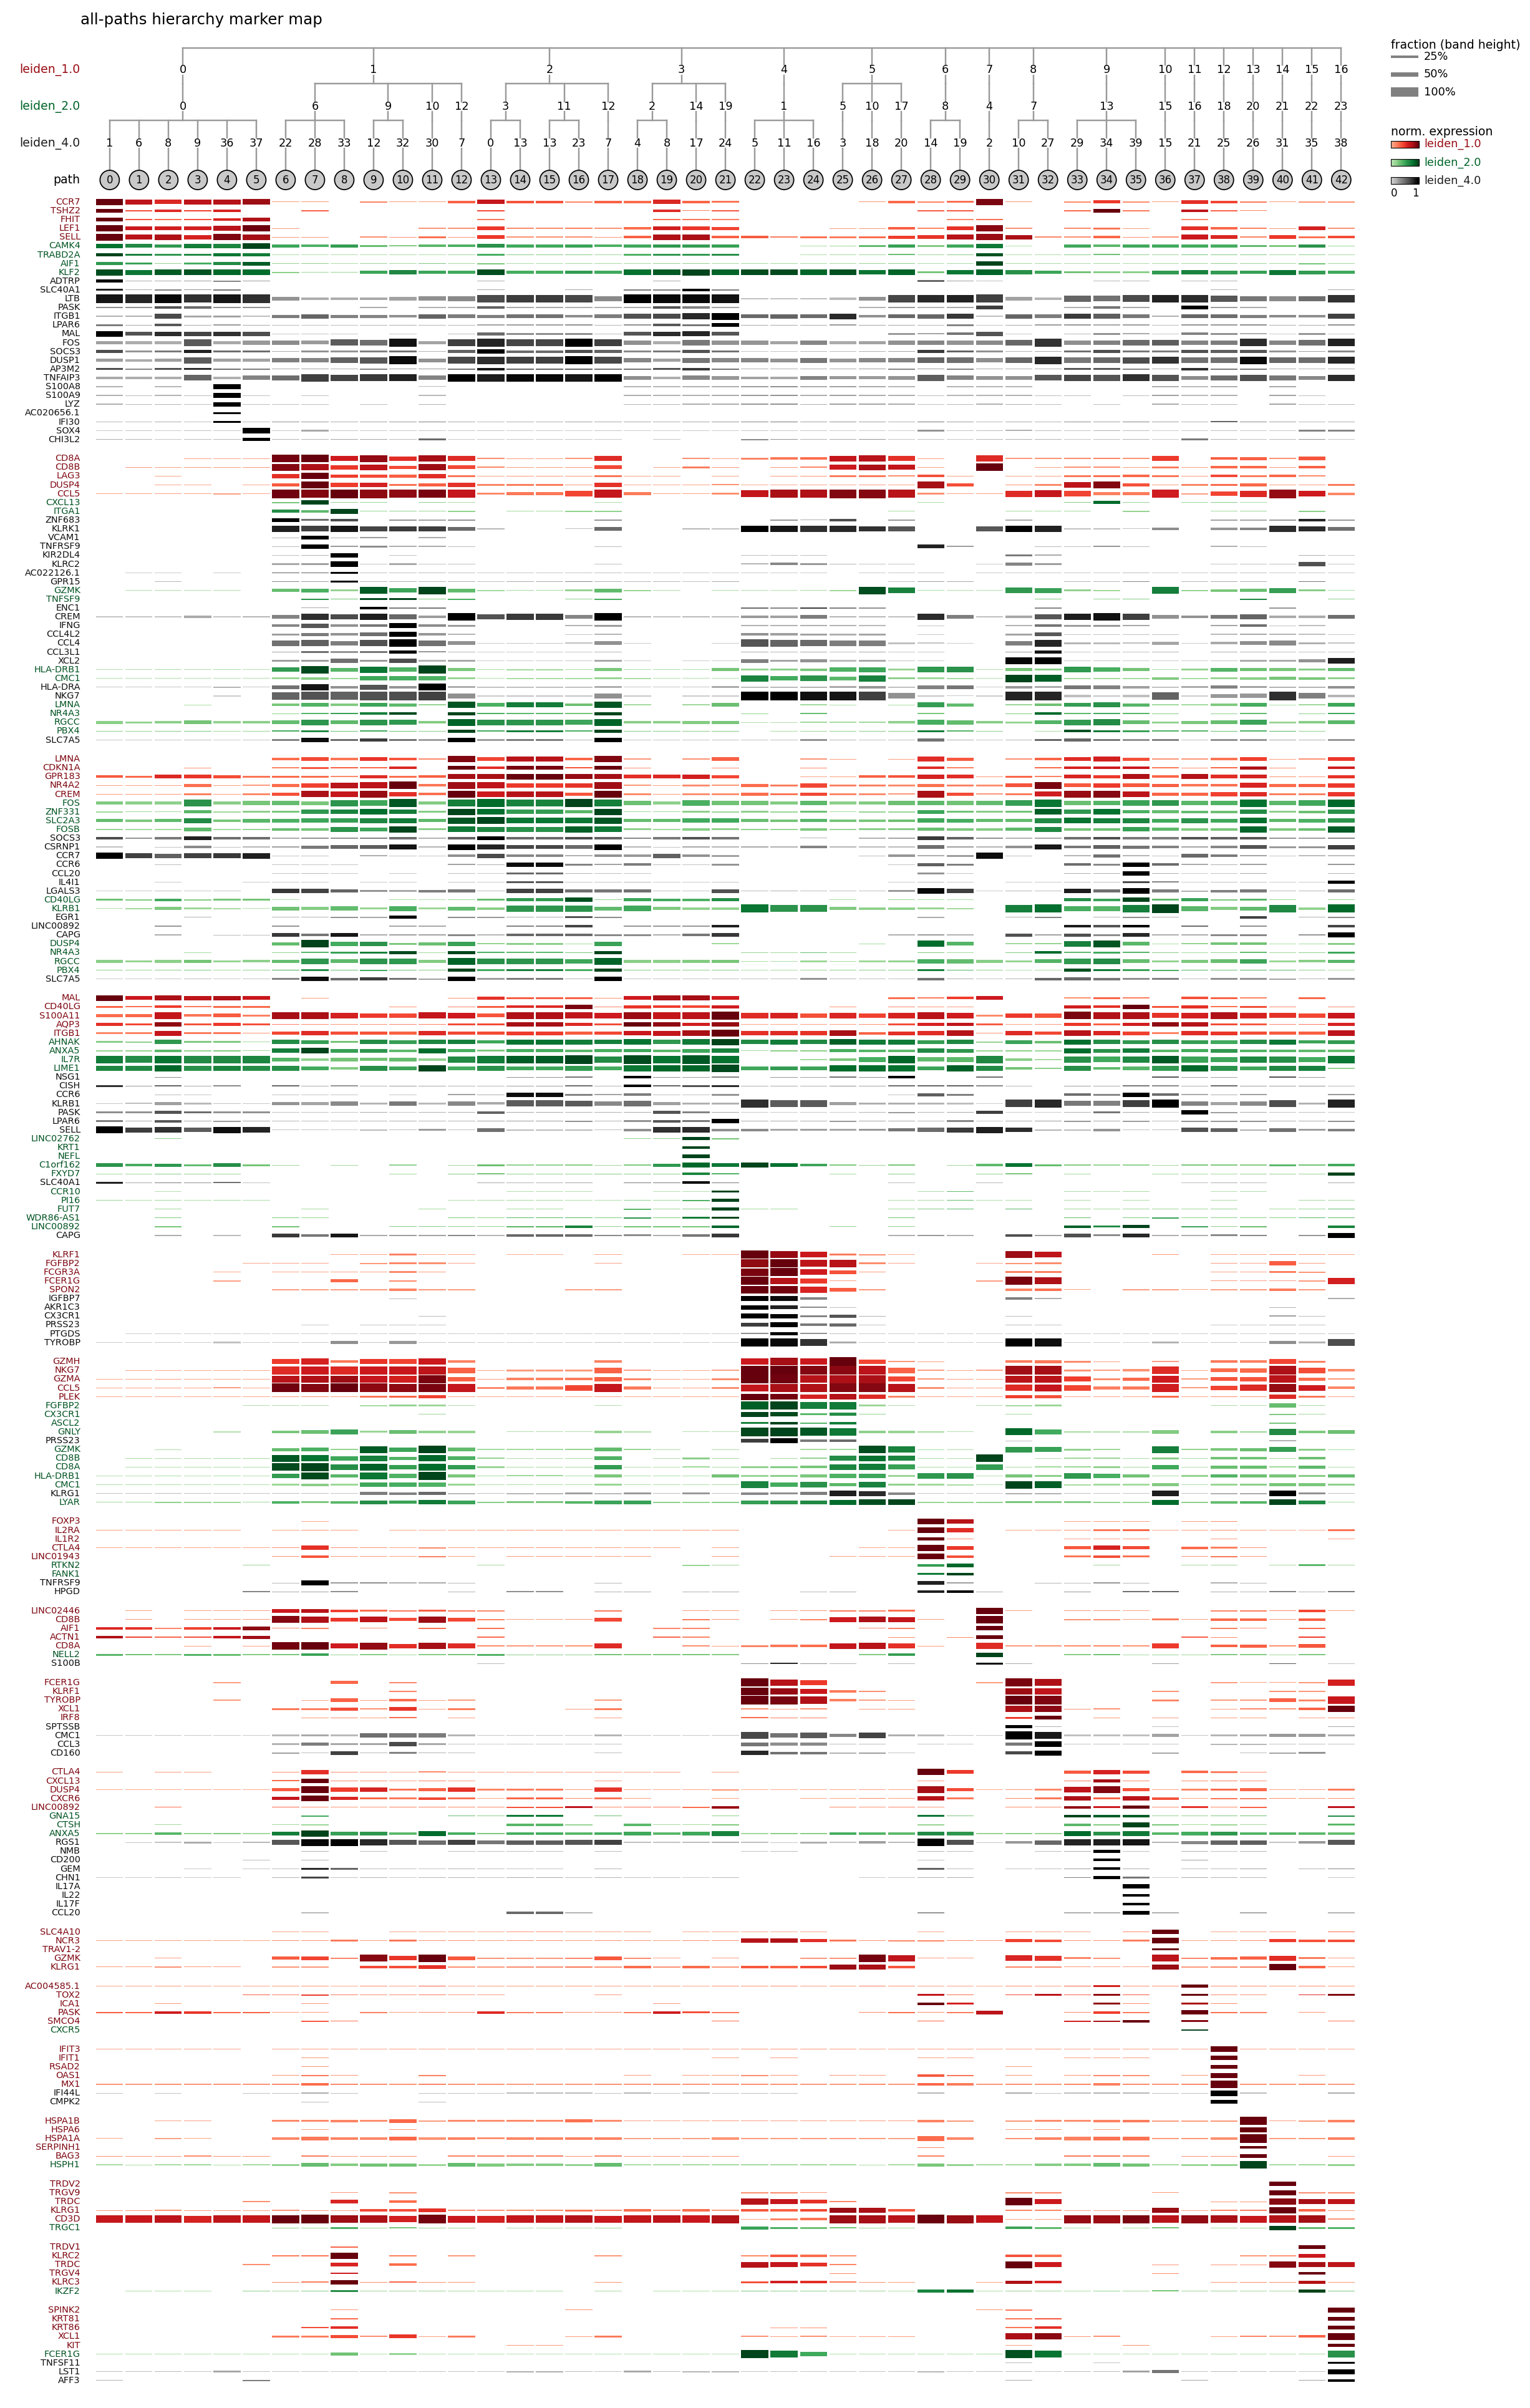

In [3]:
fig, ax = hr.marker_map(n_markers=5)
fig

## 2. Dedup: markers inherited from ancestors

By default the full `dfs` map **drops markers already shown higher up the same
lineage**, cumulative within each `leiden_1.0` subtree: a gene is kept only at the
highest level / earliest sibling it appears, and the running list resets at each
new `leiden_1.0`. This removes the repetition of, e.g., a lineage marker reappearing
at every finer level, so each level shows what is *newly* distinguishing.

Set `dedup=False` to keep every node's raw top-N (markers then repeat down a lineage):

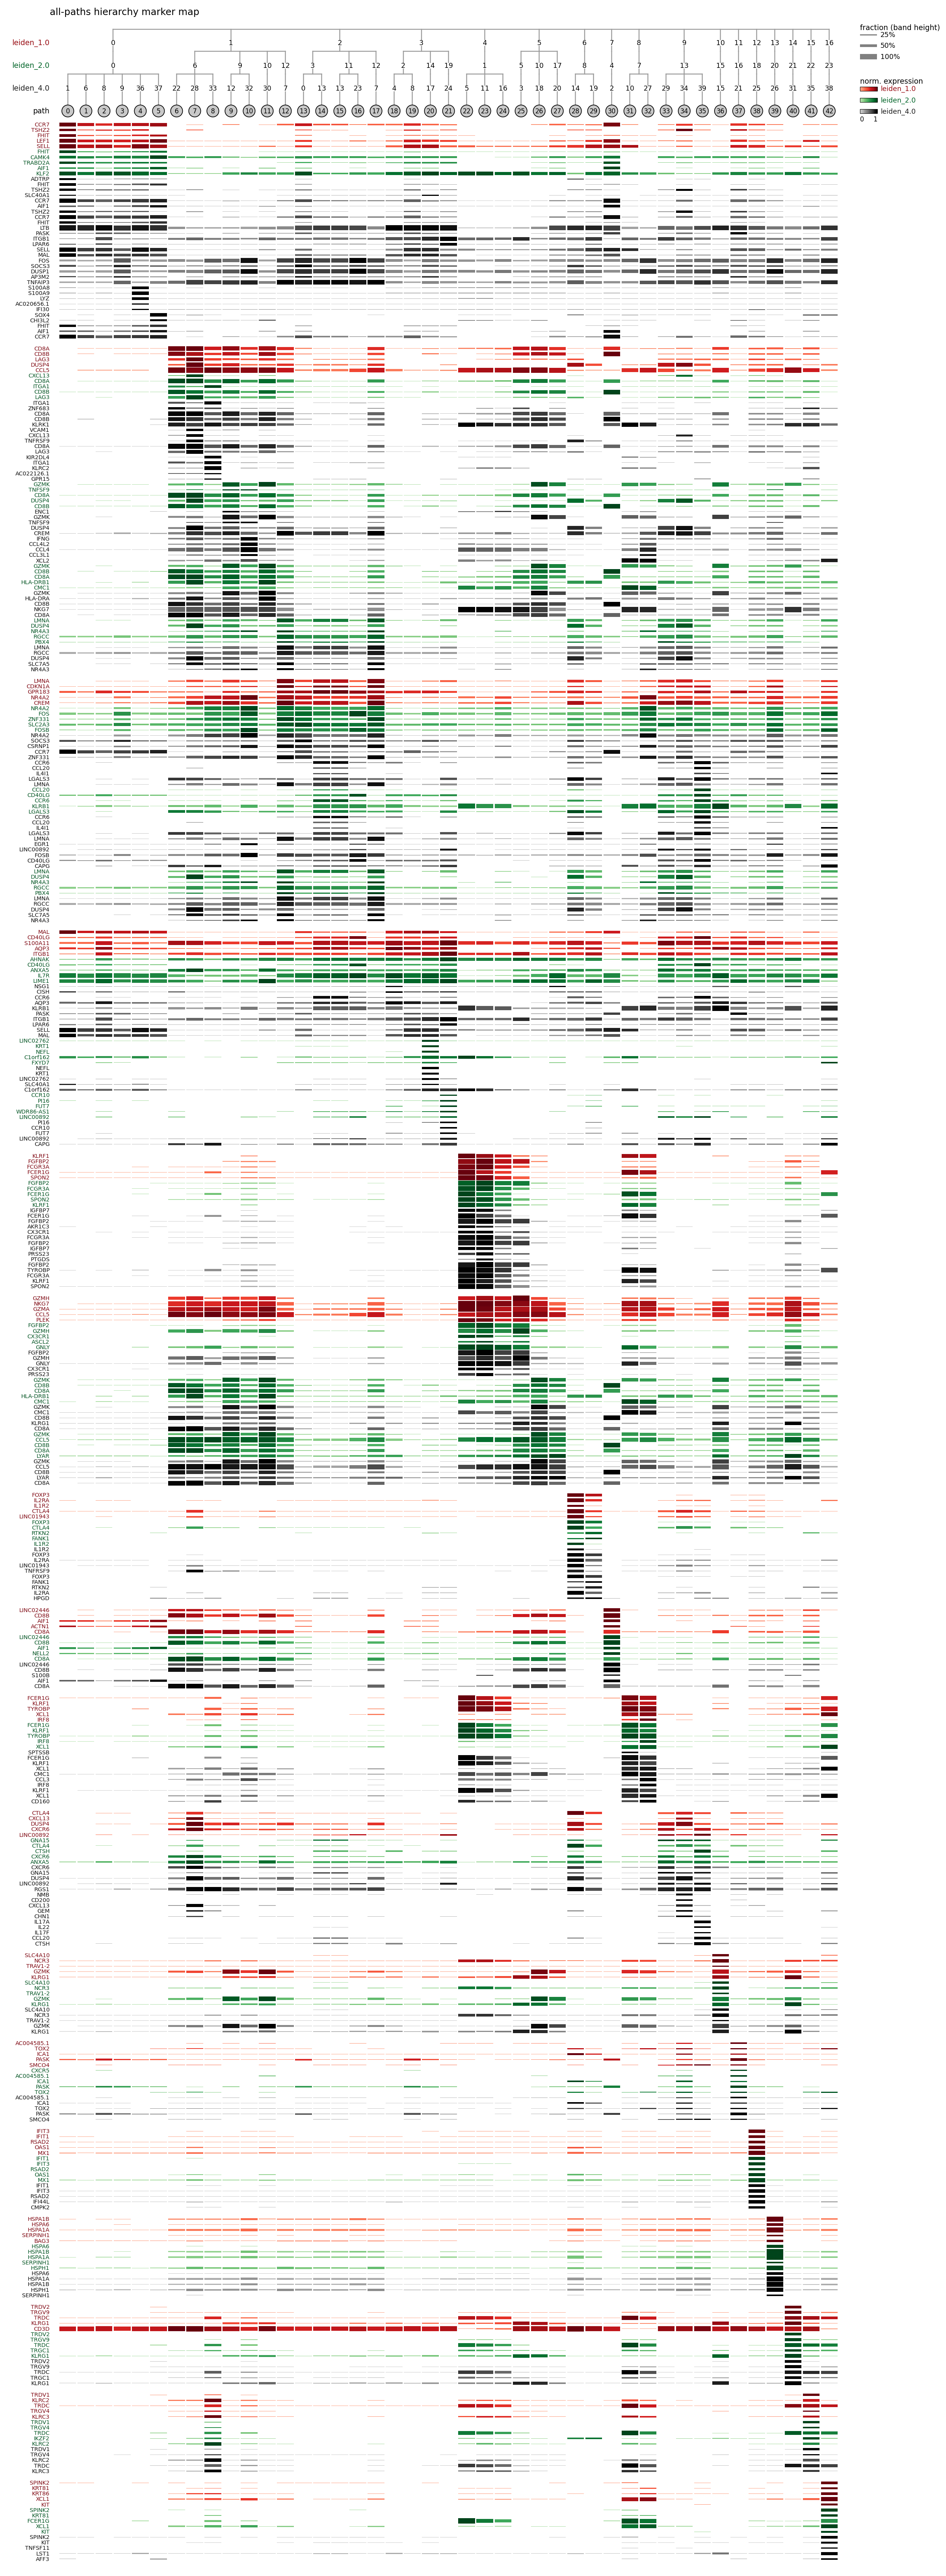

In [4]:
fig, ax = hr.marker_map(n_markers=5, dedup=False)
fig

## 3. Band vs dot

`mode="band"` (default) packs rows tightly — good for the long full map. `mode="dot"`
uses a scatter dot whose **area** is the fraction, the classic dotplot look.

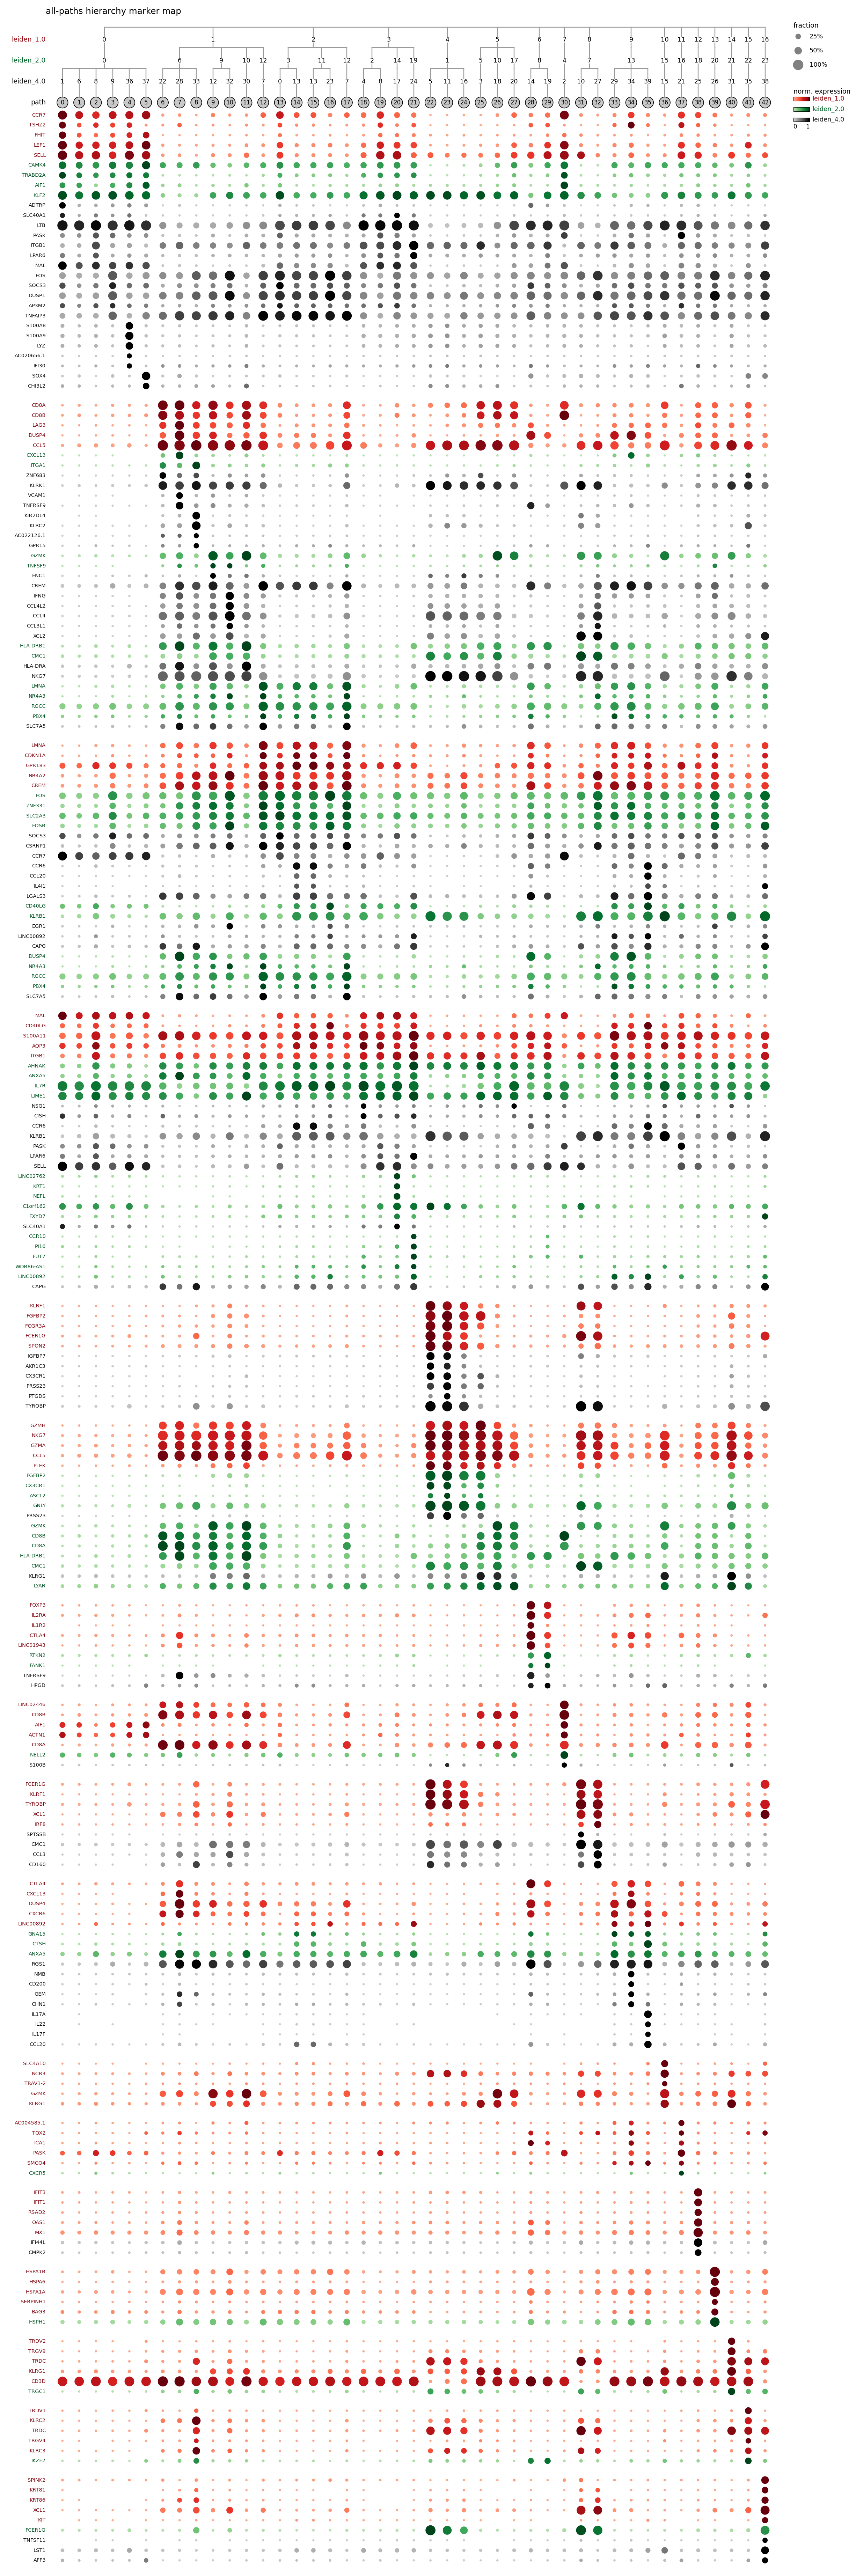

In [5]:
fig, ax = hr.marker_map(n_markers=5, mode="dot")
fig

## 4. Row ordering: dfs vs bfs

`order="dfs"` (default) groups rows by lineage/branch. `order="bfs"` stacks all
`leiden_1.0` markers, then all `leiden_2.0`, then all `leiden_4.0` — handy to compare
one resolution across the whole atlas. (Dedup is a `dfs`/lineage notion, so it is
off for `bfs`.)

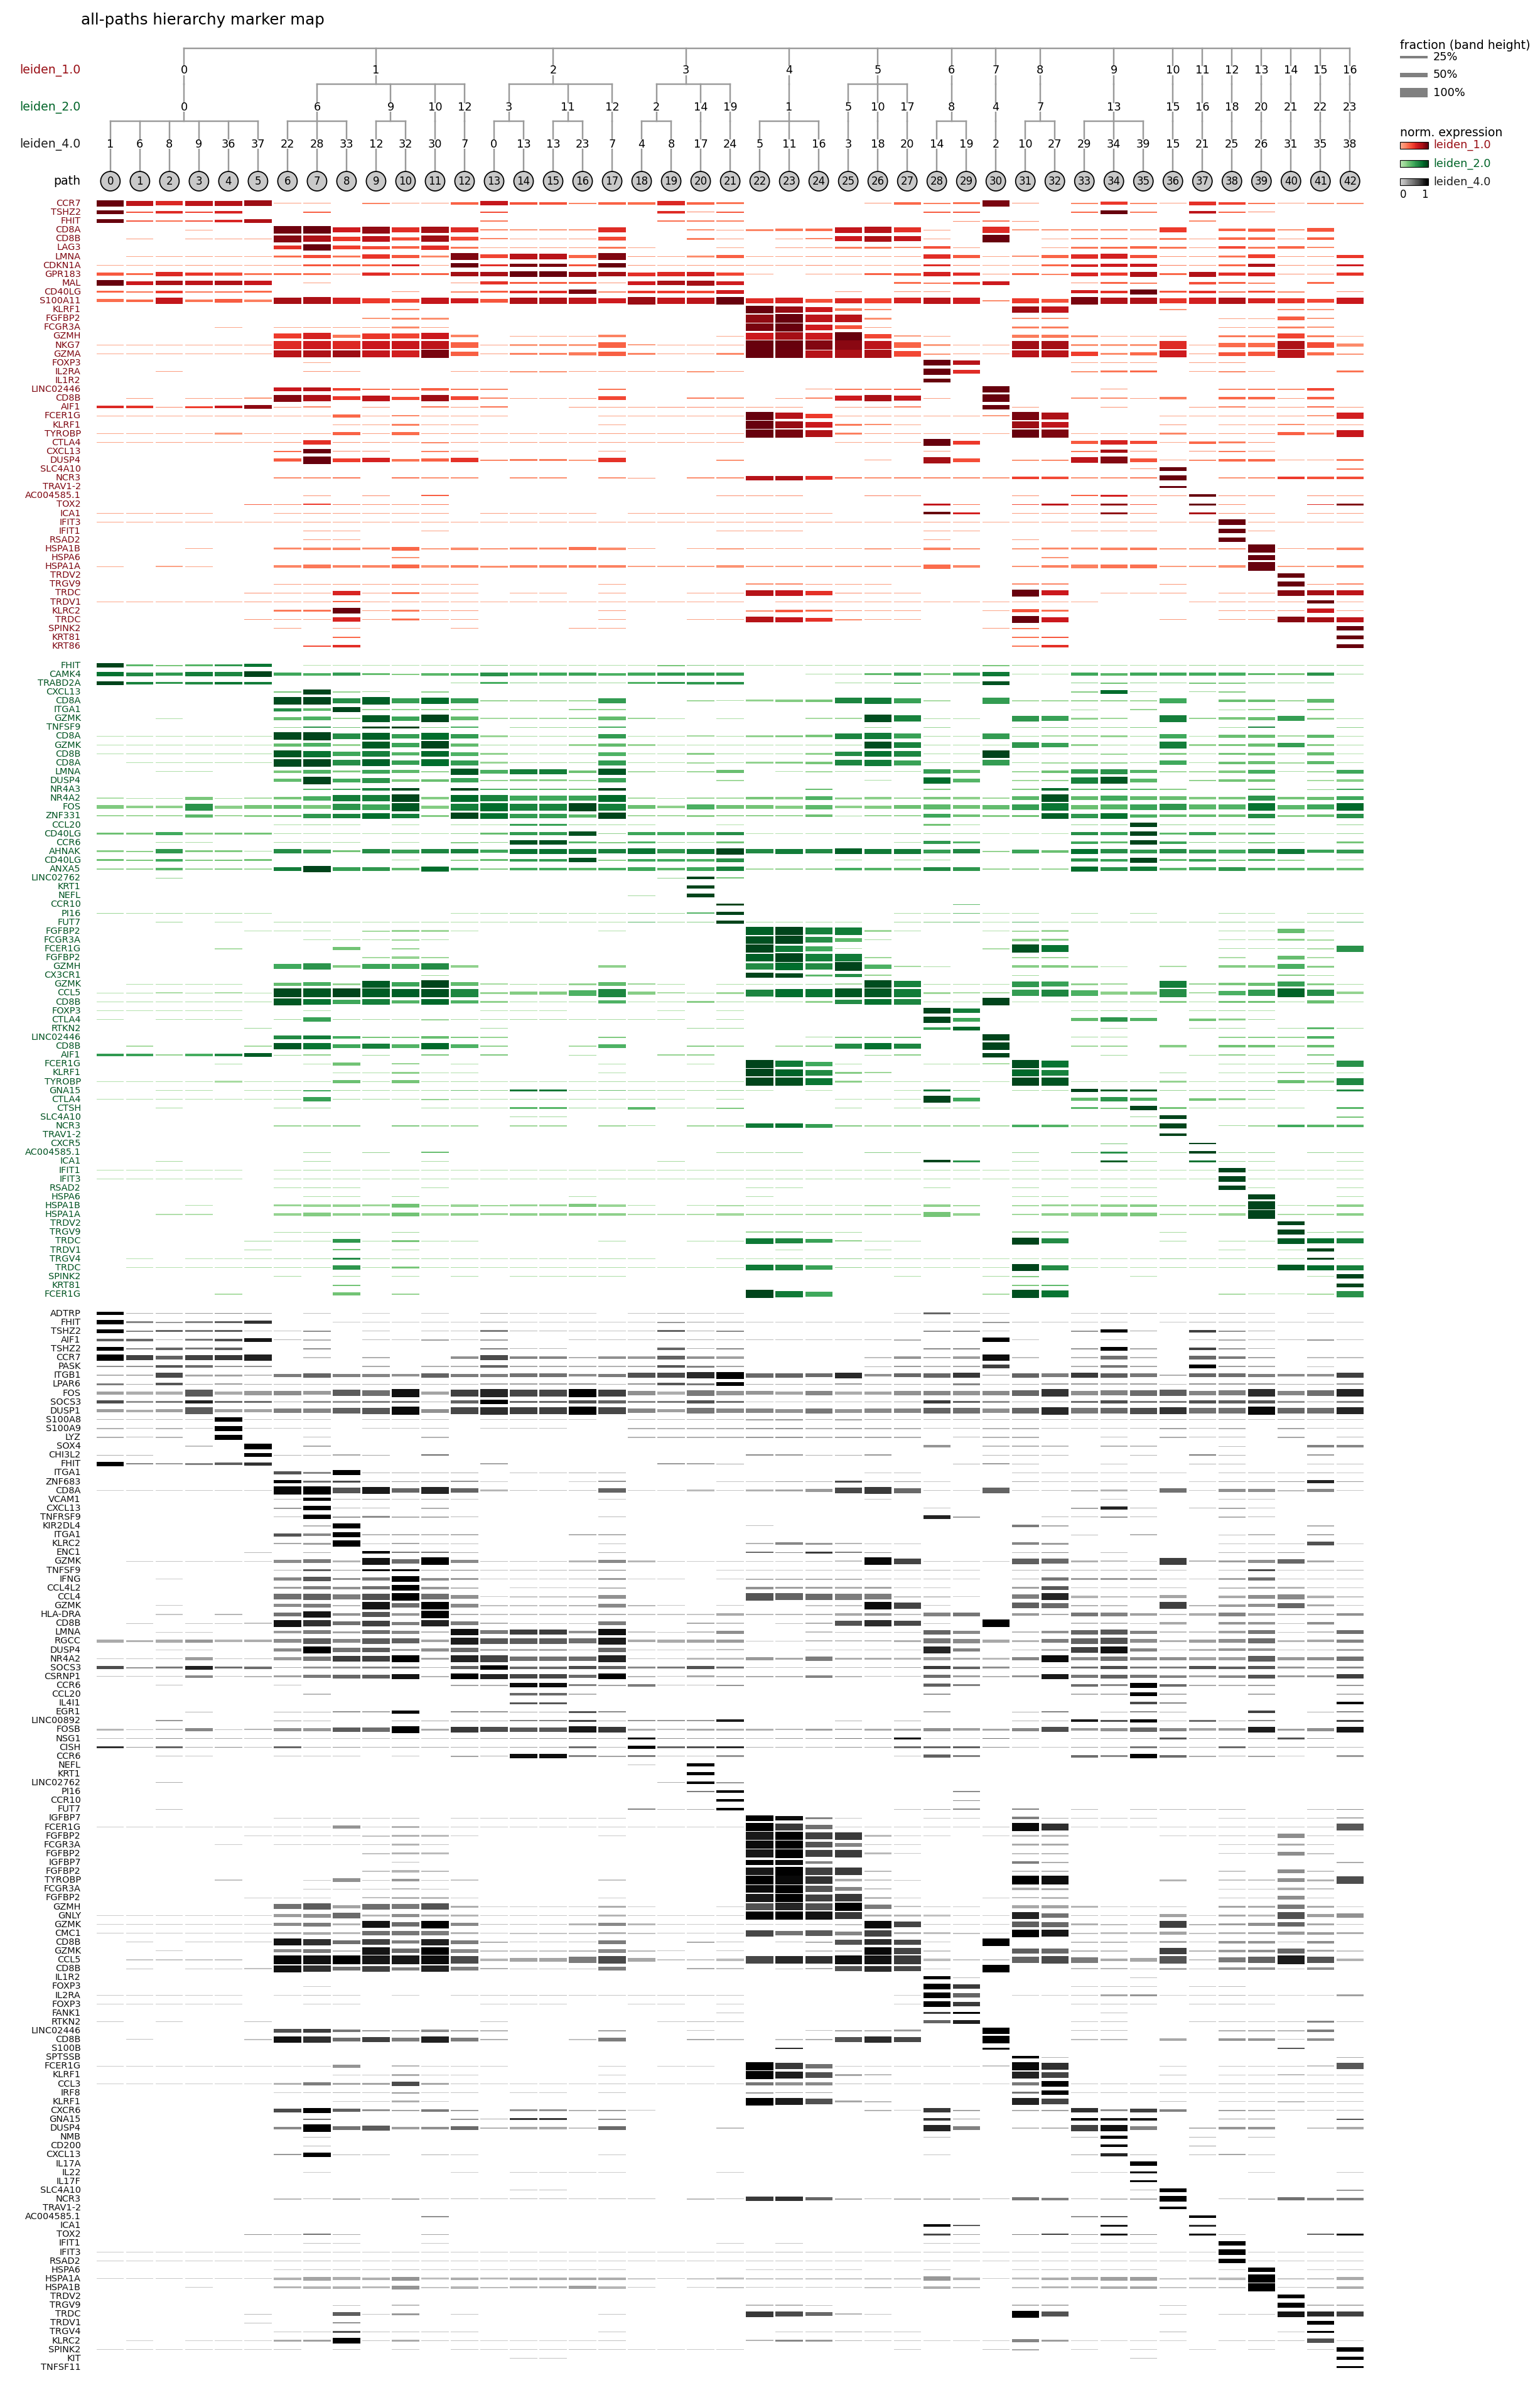

In [6]:
fig, ax = hr.marker_map(n_markers=3, order="bfs")
fig

## 5. A single path

Pass an `icls` id to focus on one lineage. Rows are that path's per-level top-N
markers (like `hr.compare_markers`, but as an expression grid), the reference column
is shaded and its circle bold, and you can read how specific each marker is across
all other leaves. Here path `0` is a naive T lineage (`CCR7`, `LEF1`, `SELL`, `MAL`).

path 0 = leiden_1.0@0|leiden_2.0@0|leiden_4.0@1


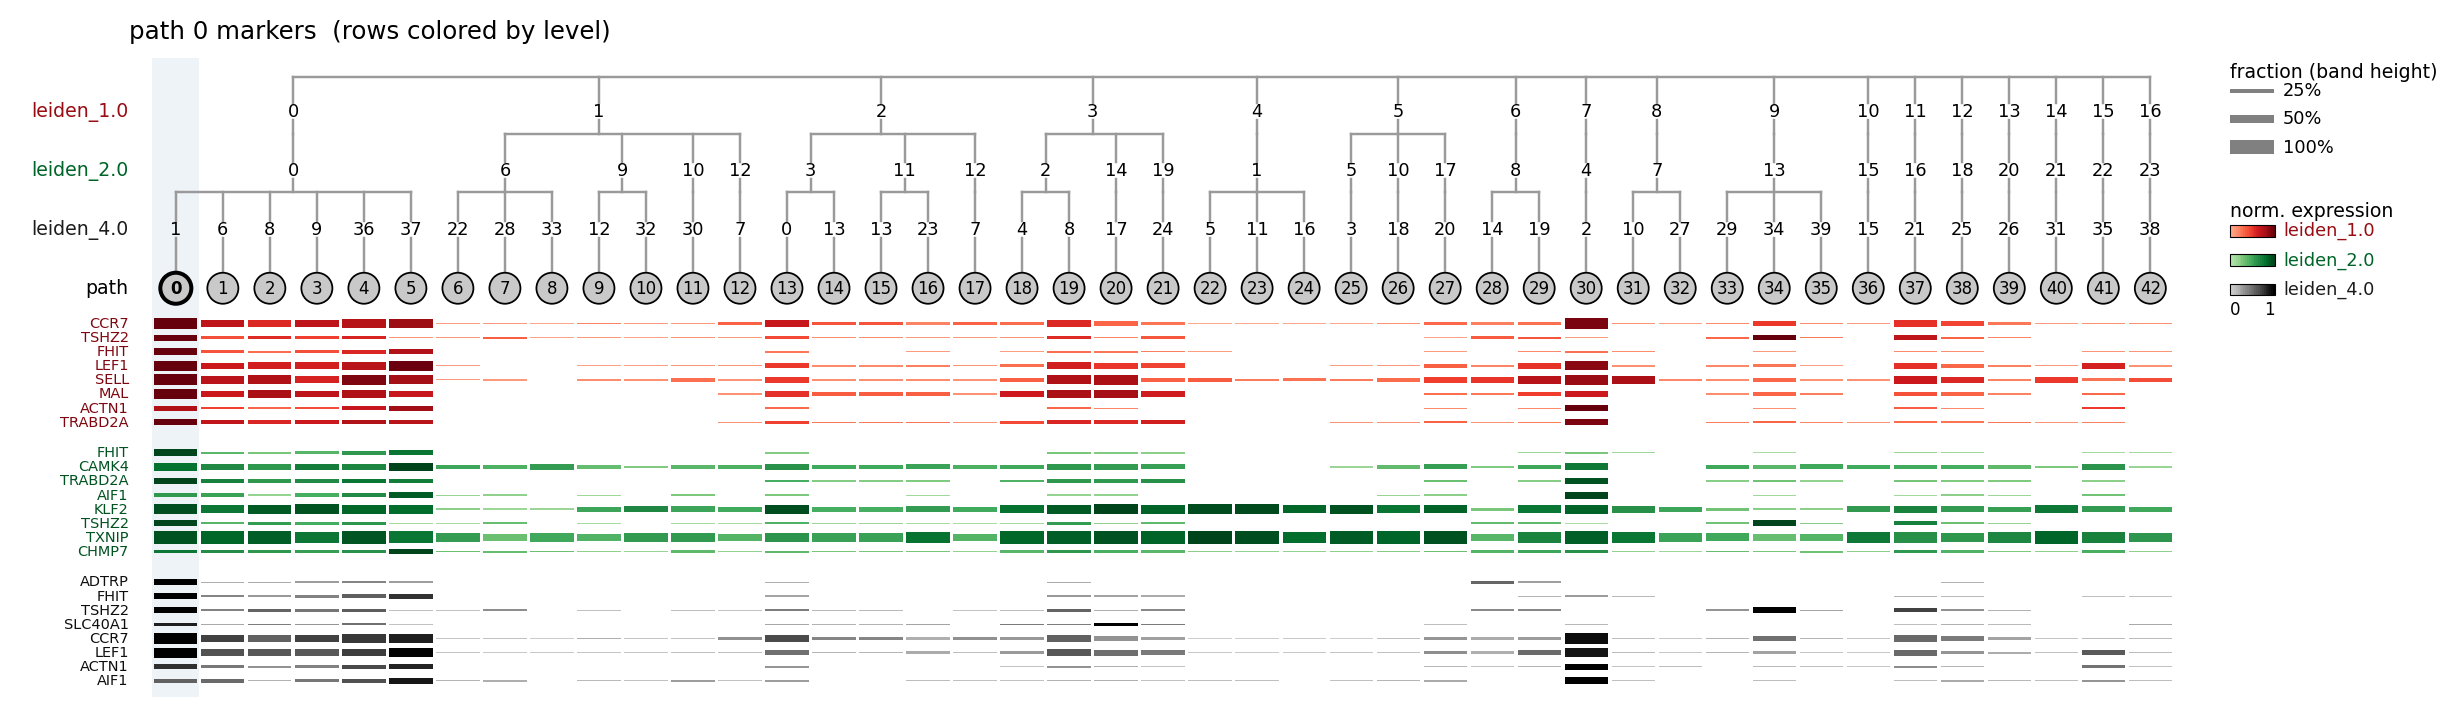

In [7]:
path0 = "0"
print("path", path0, "=", hr.icls_path_df.set_index("icls").loc[path0, "icls_full"])
fig, ax = hr.marker_map(path0, n_markers=8)
fig

On a single path, `dedup` defaults to **off** (duplicates across the 3 levels are
kept, each colored by its origin level). Set `dedup=True` to collapse the 3 levels
into a set (first occurrence wins), like `compare_markers`:

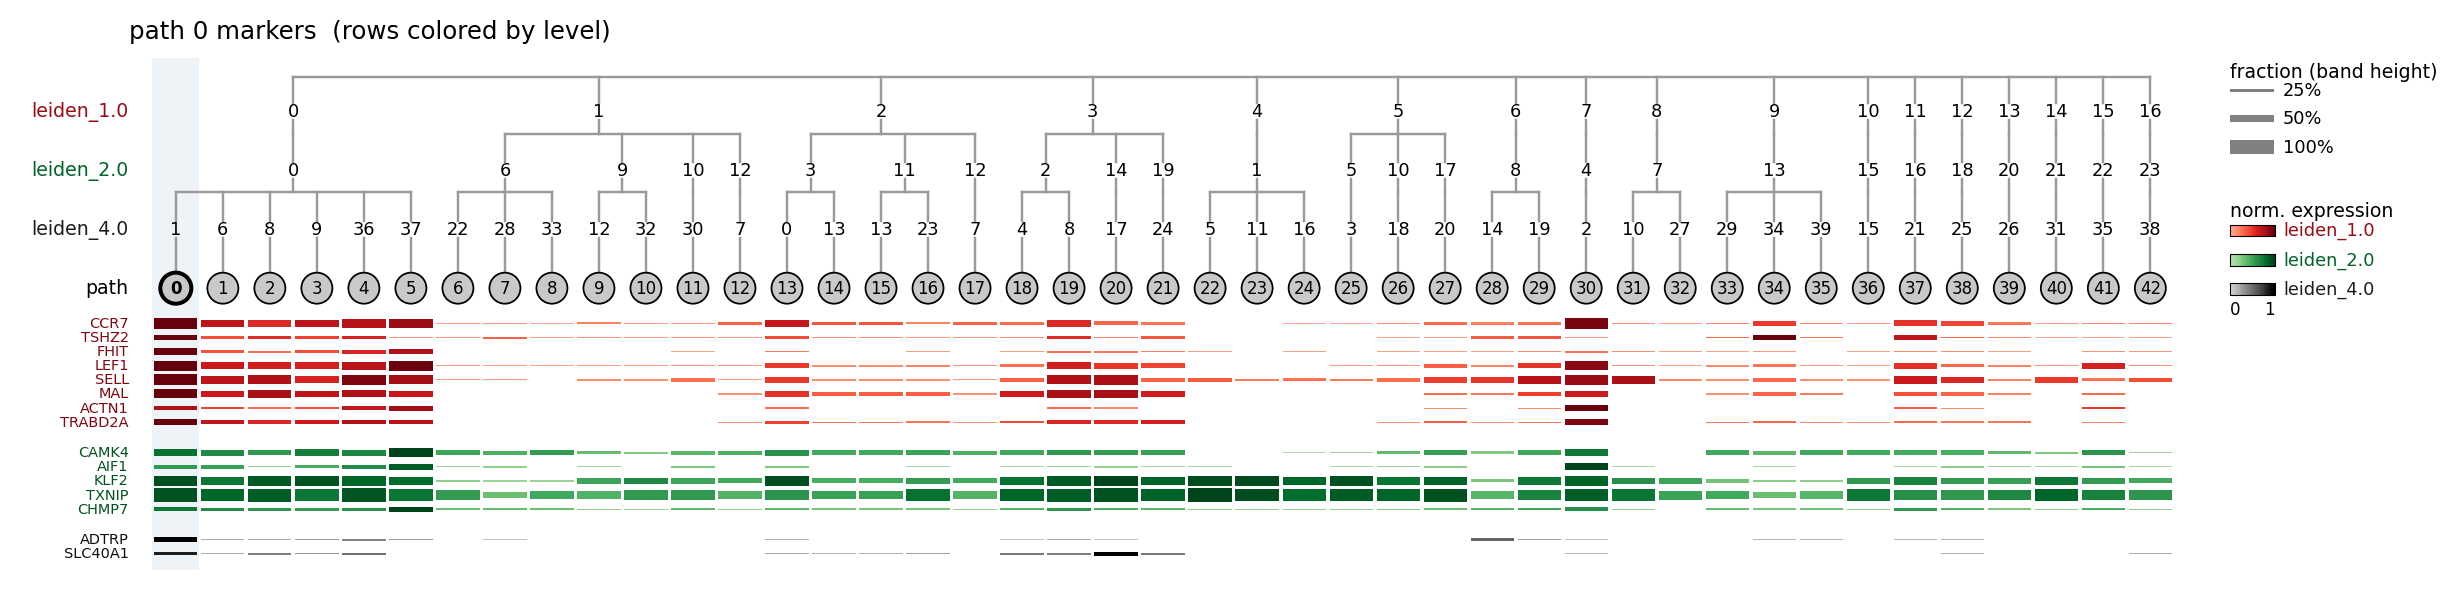

In [8]:
fig, ax = hr.marker_map(path0, n_markers=8, dedup=True)
fig

## 6. Tuning color & columns

`color_norm="global"` (default) colors by the stored atlas-wide `mean_norm`;
`color_norm="row"` rescales each gene to its max among the shown columns, which
sharpens contrast within a row.

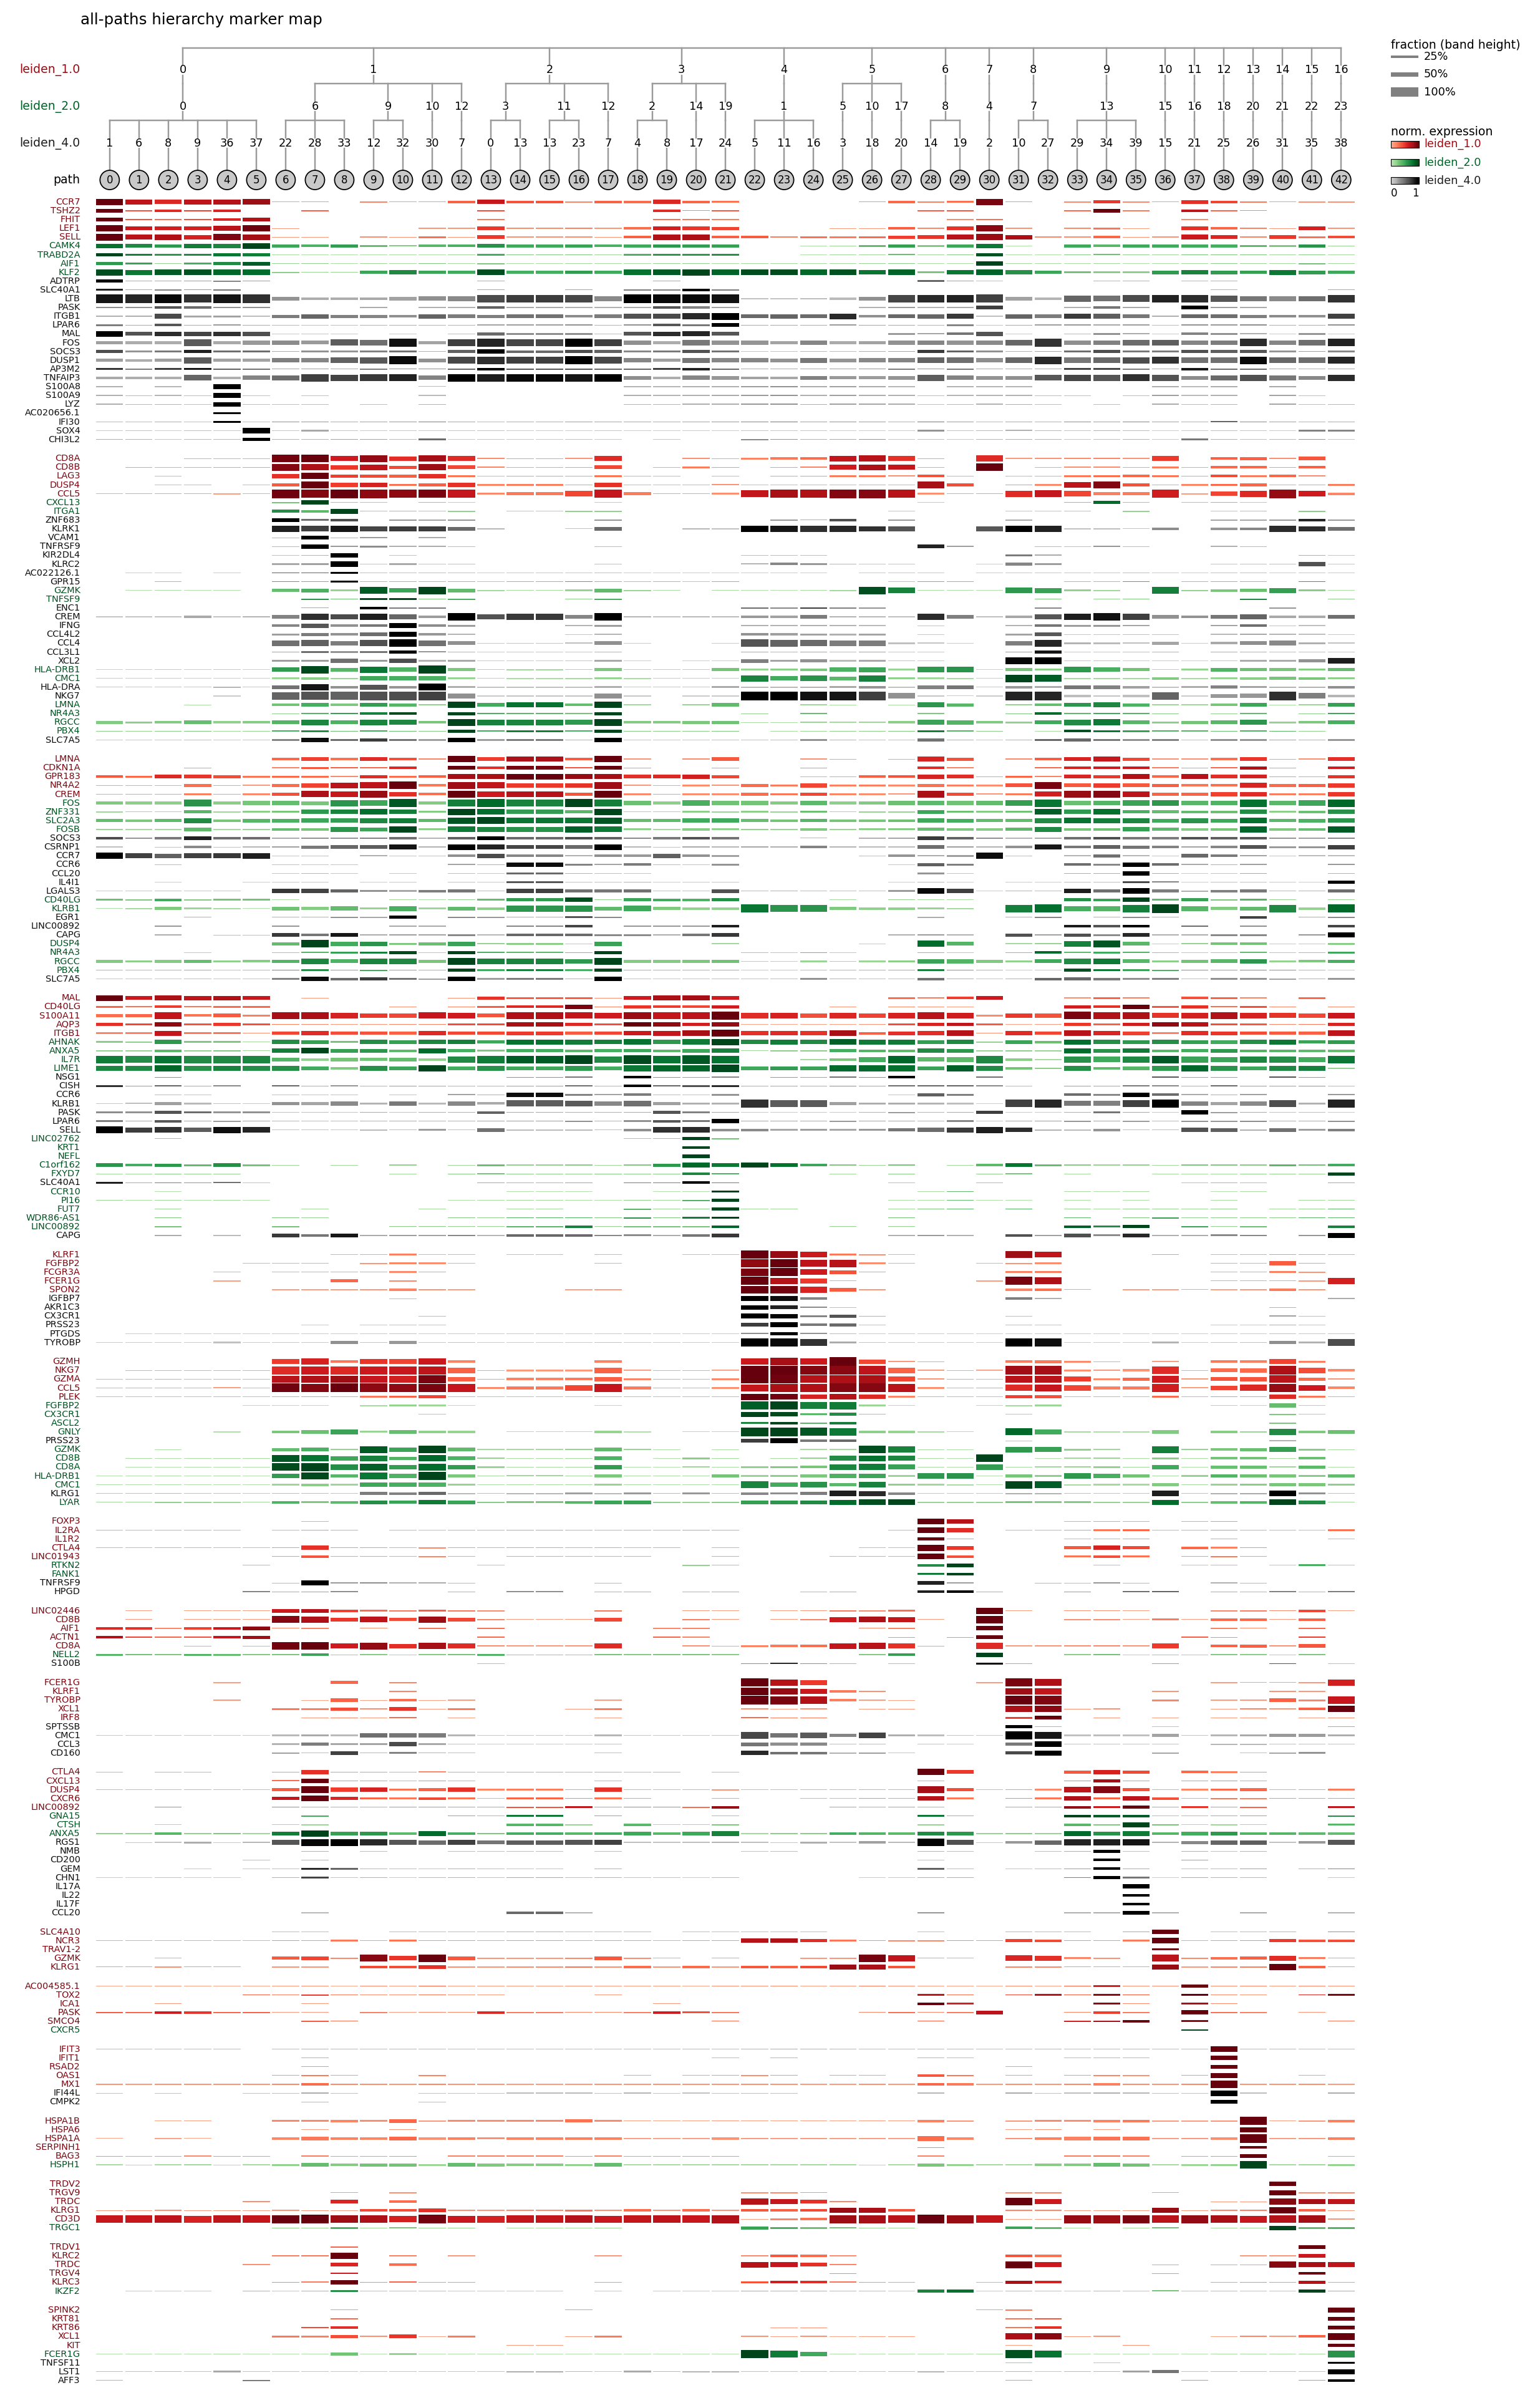

In [9]:
fig, ax = hr.marker_map(n_markers=5, color_norm="row")
fig

Restrict the columns to a subset of leaves with `columns=[...]` (always re-ordered
by the hierarchy so the tree stays planar). Combine with a single path to make a
compact, focused figure.

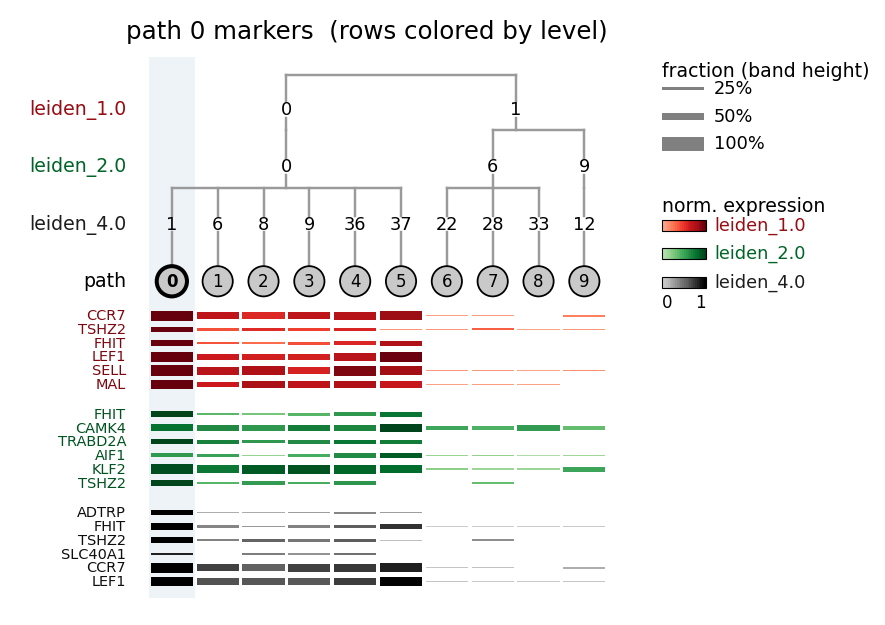

In [10]:
subset = hr.icls_path_df["icls"].tolist()[:10]
fig, ax = hr.marker_map(path0, n_markers=6, columns=subset)
fig

## Cheat-sheet

| argument | what it does |
| --- | --- |
| `icls` | `None` = full map (all nodes); `"<id>"` = single path |
| `n_markers` | top-N markers per node/level (`None` → the run's `n_top_markers`) |
| `mode` | `"band"` (height = fraction) or `"dot"` (area = fraction) |
| `order` | full map row order: `"dfs"` (lineage) or `"bfs"` (level bands) |
| `dedup` | drop ancestor-inherited markers; `None` → on for full `dfs`, off for single path / `bfs` |
| `columns` | `"all"` or a list of `icls` ids to show |
| `color_norm` | `"global"` (atlas-wide) or `"row"` (per-gene max) |
| `show_tree` | draw the hierarchy dendrogram on top |
| `highlight_ref` | single path: shade the reference column |
| `figsize`, `save` | manual size; save path (PDF, dpi=300) |

`marker_map` returns `(fig, ax)` — pass `save="marker_map.pdf"` to write a
publication-ready PDF, or keep tweaking `ax` yourself.